# Game-of-Thoughts: Evaluation of LLM Reasoning in Board Games

This project evaluates how large language models perform on structured reasoning tasks using two classic games:

- Tic-Tac-Toe (3×3 grid)  
- Connect Four (6×7 grid)  

The goal is to analyze whether models can:
- understand game rules,
- detect rule violations,
- generate valid game states,
- and simulate multi-step gameplay consistently.

---

## Models Used

The experiments were conducted using:

- llama-3.1-8b-instant  
- qwen/qwen3-32b  

Both models were accessed through the **Groq API**, which provides a free usage tier. This made it possible to run multiple experiments efficiently with fast inference.

Initially, I also experimented with Gemini models. However, due to stricter rate limits and slower execution for large batches, it was difficult to scale the experiments. I therefore switched to Groq-based models to ensure smoother and more consistent evaluation.

---

## Tasks Evaluated

The project includes the following evaluation tasks:

- Rule Understanding: whether the model can correctly describe and follow game rules  
- Rule Error Detection: whether the model can identify invalid or inconsistent game states  
- Game Generation: ability to generate valid and playable boards  
- Game Simulation: step-by-step gameplay following game constraints  

---

## Notebook Structure

This notebook presents:

- aggregated results for each task  
- visual summaries of model performance  
- reconstructed gameplay traces for selected cases  
- analysis of model strengths and limitations  

Only clean simulation cases are shown for reconstruction. Cases where the initial board already satisfied the win condition or where gameplay continued after a terminal state are excluded to ensure clarity and correctness of analysis.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)


Project root: /workspaces/game-of-thoughts


In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from src.analysis.experiment_utils import find_project_root

ROOT = find_project_root(ROOT)
RESULTS_DIR = ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
PLOTS_DIR = RESULTS_DIR / "plots"

summary_df = pd.read_csv(TABLES_DIR / "all_experiments_summary_latest.csv")
sim_df = pd.read_csv(TABLES_DIR / "all_simulation_results.csv")

display(Markdown("## Execution status"))
display(summary_df)


## Execution status

,experiment,game,model,exit_code,status
0,rule_understanding,tictactoe,llama-3.1-8b-instant,0,success
1,rule_understanding,tictactoe,qwen/qwen3-32b,0,success
2,rule_understanding,connect_four,llama-3.1-8b-instant,0,success
3,rule_understanding,connect_four,qwen/qwen3-32b,0,success
4,game_simulation,tictactoe,llama-3.1-8b-instant,0,success
5,game_simulation,tictactoe,qwen/qwen3-32b,0,success
6,game_simulation,connect_four,llama-3.1-8b-instant,0,success
7,game_simulation,connect_four,qwen/qwen3-32b,0,success
8,rule_error_detection,tictactoe,llama-3.1-8b-instant,0,success
9,rule_error_detection,tictactoe,qwen/qwen3-32b,0,success


## 1. Overall execution status

The table above shows that the main experiments were executed successfully across the available model and game combinations.  
This matters for the submission because it demonstrates that the project is not just a design concept: the pipeline actually ran end-to-end.

The project covers three existing reasoning tasks in a structured way:
1. **Rule understanding**
2. **Rule error detection**
3. **Game simulation**
4. **Game generation**


Together, these test whether a model can understand a rule system, critique a broken rule system, and then act within that rule system during play.


## 2. Rule understanding

This task evaluates whether a model can read a game description and recover the essential rule slots correctly.

The combined plot below reports:
- **Precision**: how much of what the model says is correct,
- **Recall / completeness**: how much of the gold rule schema it covers,
- **F1**: the balance between the two.

Even without raw per-example CSVs in this snapshot, the saved plot already preserves the key comparative result.


In [3]:
import pandas as pd
from pathlib import Path
from src.analysis.experiment_utils import find_project_root

root = find_project_root()

rule_df = pd.read_csv(root / "results" / "responses" /"rule_understanding"/ "rule_understanding_results.csv")

display(rule_df)

,model,game,completeness,precision,f1,correct_items,filled_items,total_items,missing_items,incorrect_items,hallucinated_items
0,llama,connect_four,0.333333,0.333333,0.333333,3,9,9,NaN,"board_size, players, turn_order, move_type, gr...","manual_row_choice, wrong_win_condition, allow_..."
1,qwen,connect_four,0.555556,0.555556,0.555556,5,9,9,NaN,"players, turn_order, gravity, illegal_full_column","manual_row_choice, wrong_win_condition, allow_..."
2,llama,tictactoe,0.500000,0.571429,0.533333,4,7,8,start_player,"board_size, players, legal_move",three_players
3,qwen,tictactoe,0.750000,0.750000,0.750000,6,8,8,NaN,"board_size, players","three_players, free_symbol_choice, occupied_sp..."


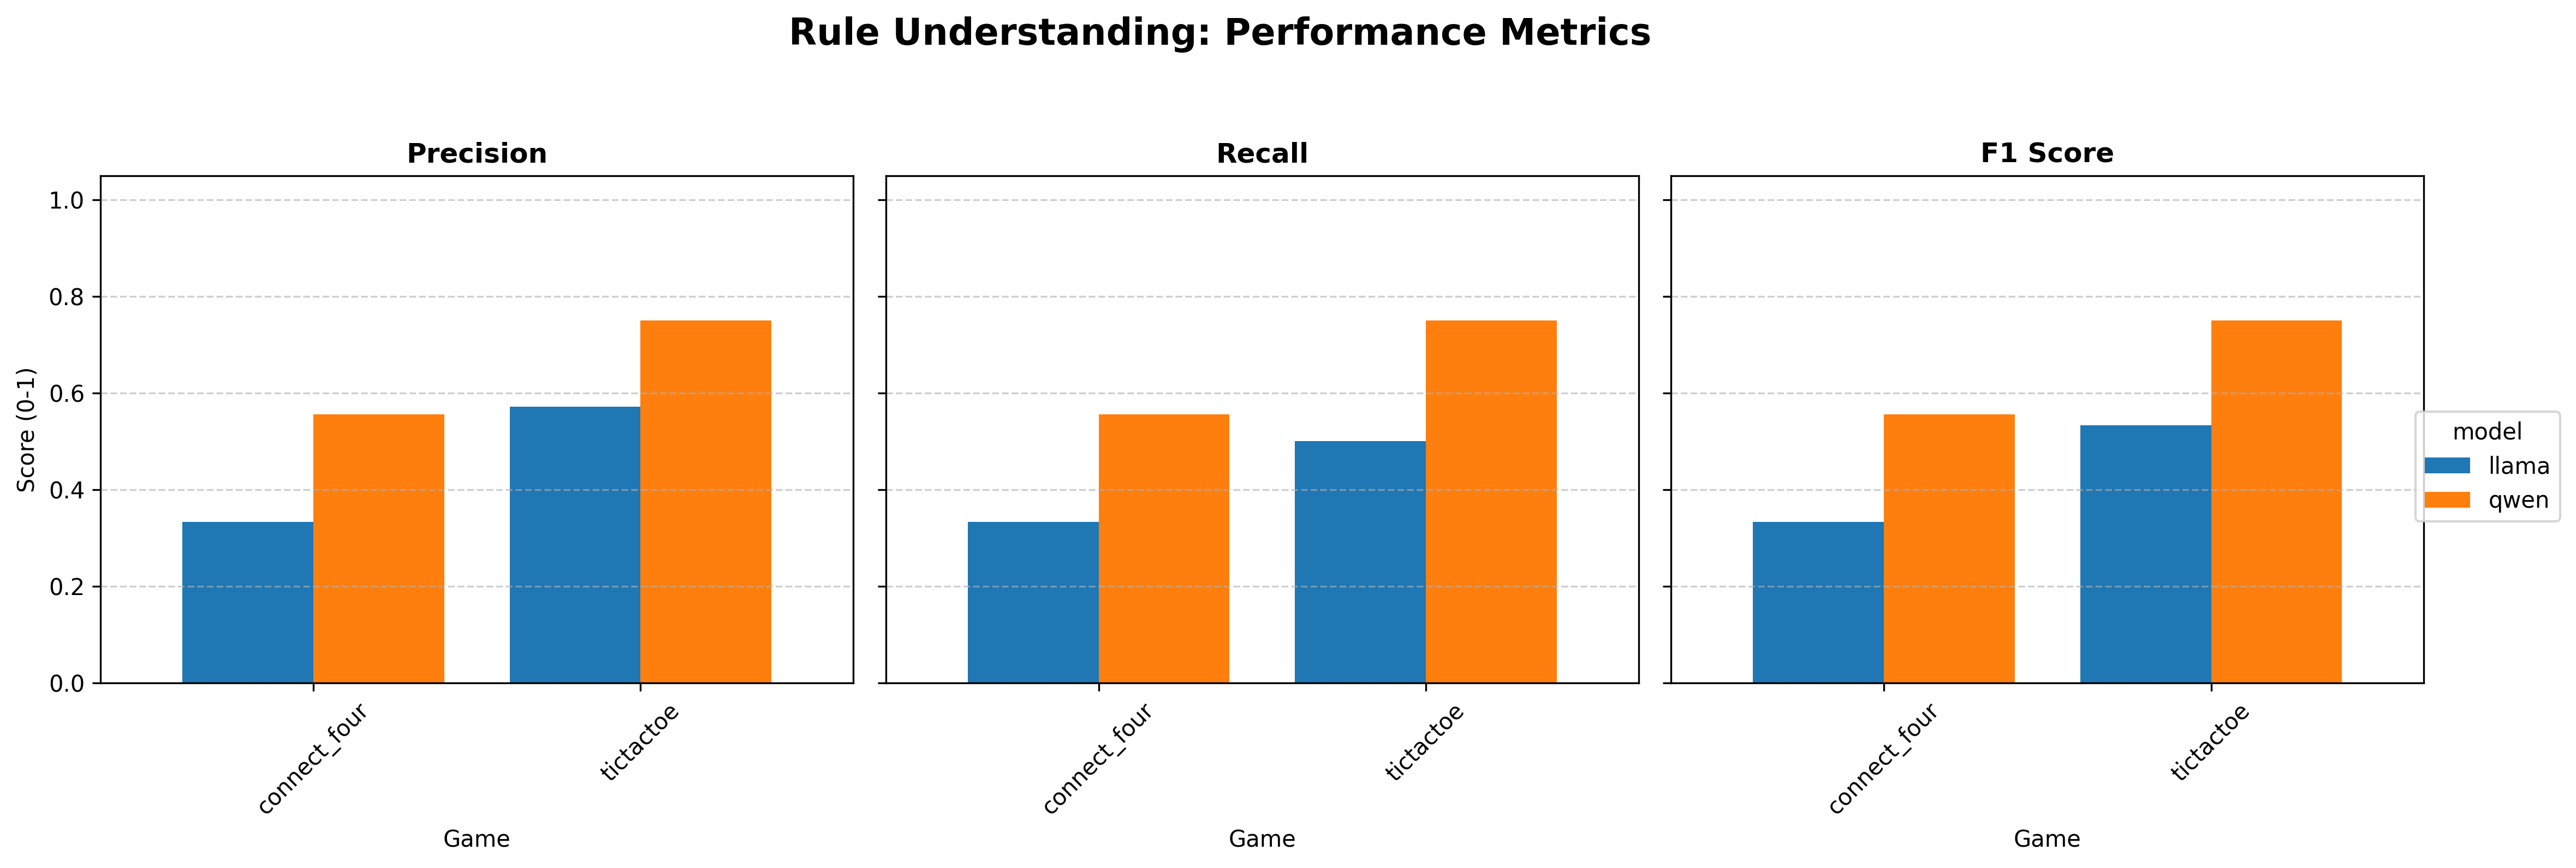

In [4]:
ru_plot = PLOTS_DIR / "summary_rule_understanding_combined.png"
display(Image(filename=str(ru_plot), width=1200))


### Analysis

Qwen outperforms Llama on both games, with higher completeness and F1 scores. Performance is lower for Connect Four (~0.33–0.56) compared to Tic-Tac-Toe, reflecting the increased complexity of rules such as gravity and win conditions.

Both models miss key rule components and sometimes introduce incorrect or hallucinated rules, indicating incomplete understanding. Overall, models handle simpler rule systems better, with Qwen showing more consistent performance.

## 3. Rule error detection

This task checks whether the models can recognize inconsistencies or mistakes in intentionally broken rules.

The plot below reports:
- **Precision**: whether detected issues are actually relevant,
- **Recall**: how often the model notices that something is wrong,
- **F1**: the overall balance.


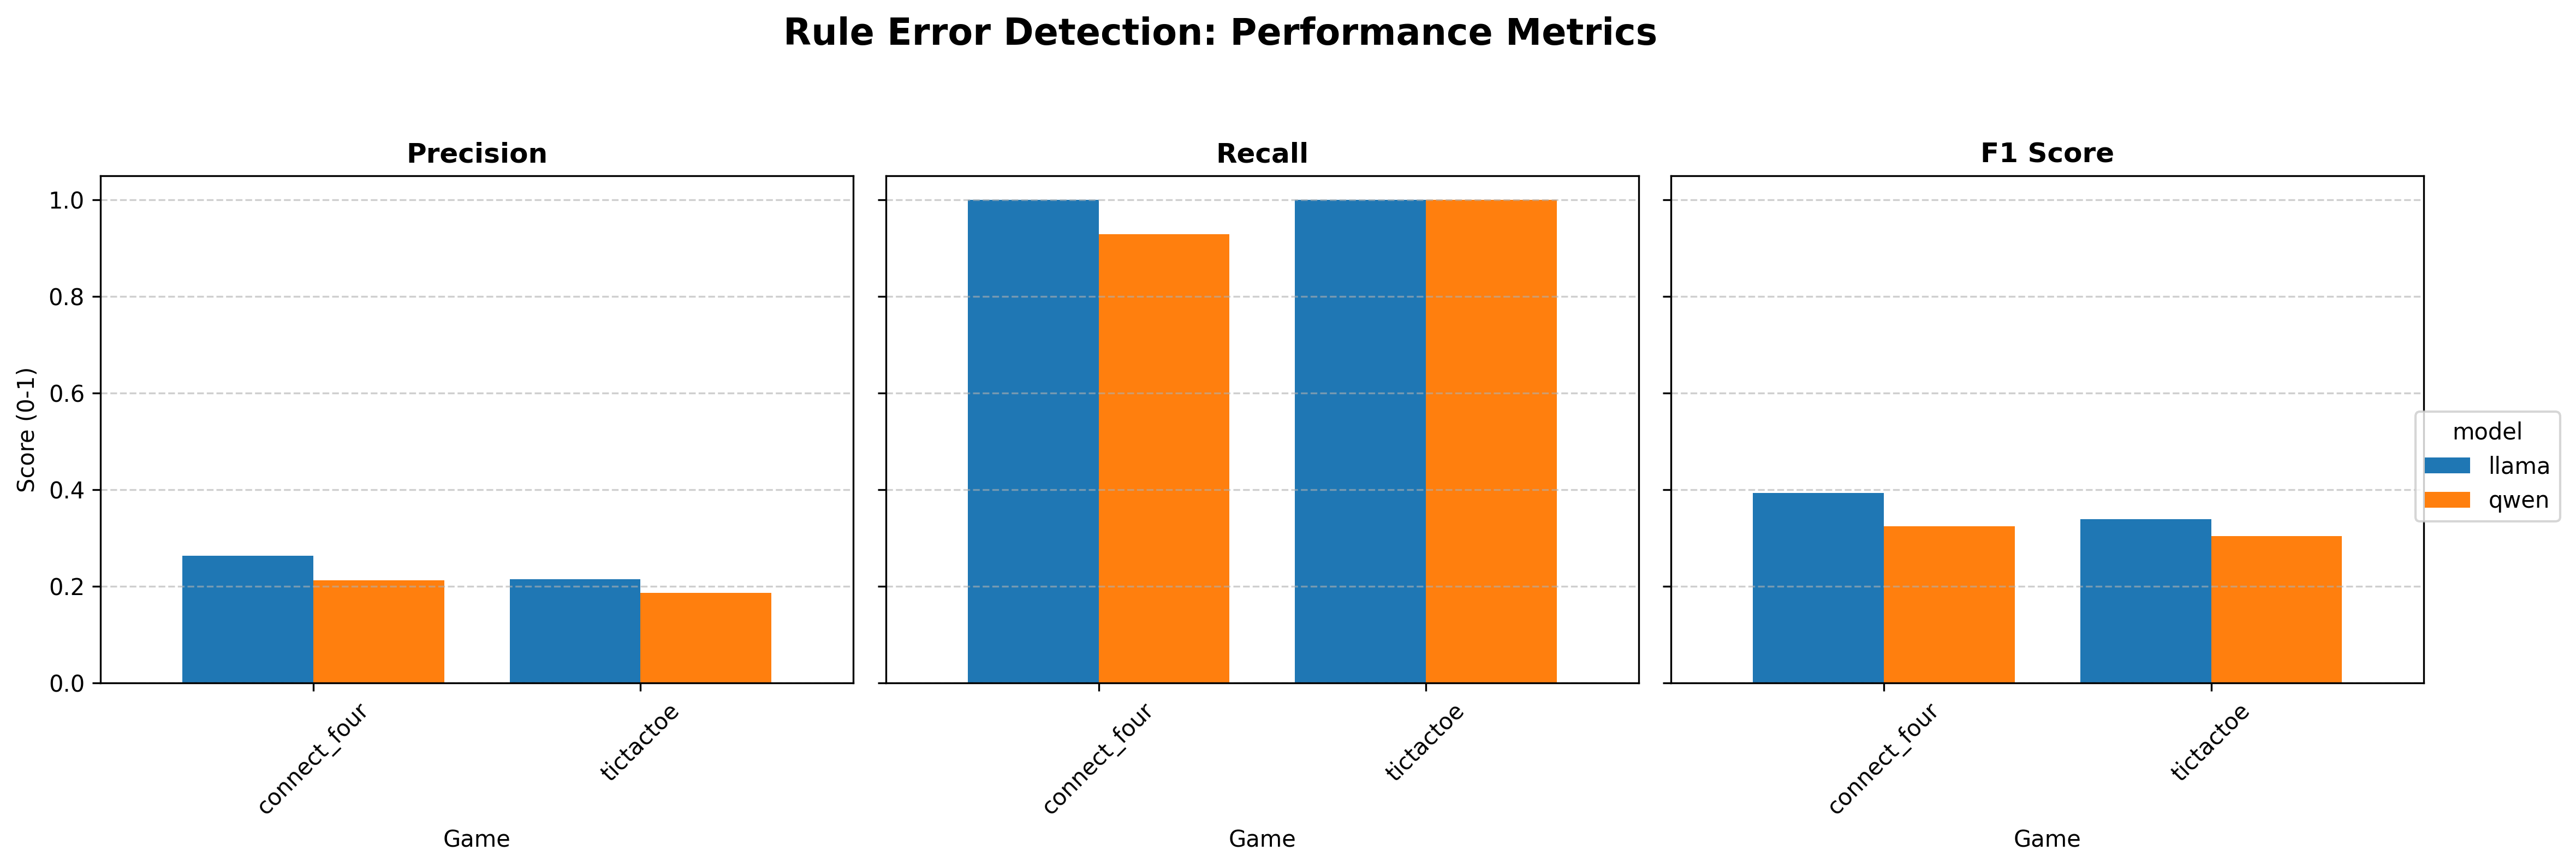

In [5]:
re_plot = PLOTS_DIR / "summary_rule_error_combined.png"
display(Image(filename=str(re_plot), width=1200))


### Results and Analysis

Rule error detection was evaluated by comparing each model response against the gold error annotations provided for each case. Precision, recall, and F1 score were computed per case and then averaged by model and game.

Both models achieve high recall, showing that they usually detect that a rule is incorrect. However, precision is much lower, which means they often include extra or inaccurate claims. Llama performs slightly better overall, but both models struggle with precise error identification.

## 4. Game simulation

This is the strongest procedural task in the project.

Instead of only asking for verbal descriptions, the simulation task tests whether the model can:
- continue a game from a given board,
- obey legality constraints,
- maintain consistency across multiple turns,
- and reach a valid terminal state.

The table and plots below are generated directly from `results/tables/all_simulation_results.csv`.


In [6]:
sim_summary = (
    sim_df.groupby(["model", "game"], as_index=False)
    .agg(
        cases=("case_id", "count"),
        avg_valid_turns=("valid_turns", "mean"),
        avg_total_turns=("total_turns", "mean"),
        completion_rate=("stopped_reason", lambda s: (s == "terminal_state_reached").mean()),
        invalid_stop_rate=("stopped_reason", lambda s: (s == "invalid_move").mean()),
        x_win_rate=("winner", lambda s: (s == "X").mean()),
        o_win_rate=("winner", lambda s: (s == "O").mean()),
        draw_rate=("winner", lambda s: (s.str.lower() == "draw").mean()),
    )
)
sim_summary["legal_move_rate"] = sim_summary["avg_valid_turns"] / sim_summary["avg_total_turns"]
sim_summary = sim_summary.round(3)

display(sim_summary)


,model,game,cases,avg_valid_turns,avg_total_turns,completion_rate,invalid_stop_rate,x_win_rate,o_win_rate,draw_rate,legal_move_rate
0,llama-3.1-8b-instant,connect_four,50,5.38,5.78,0.60,0.40,0.34,0.26,0.00,0.931
1,llama-3.1-8b-instant,tictactoe,50,3.62,3.70,0.92,0.08,0.48,0.30,0.14,0.978
2,qwen/qwen3-32b,connect_four,50,4.04,4.36,0.68,0.32,0.42,0.26,0.00,0.927
3,qwen/qwen3-32b,tictactoe,50,3.54,3.56,0.98,0.02,0.44,0.42,0.12,0.994


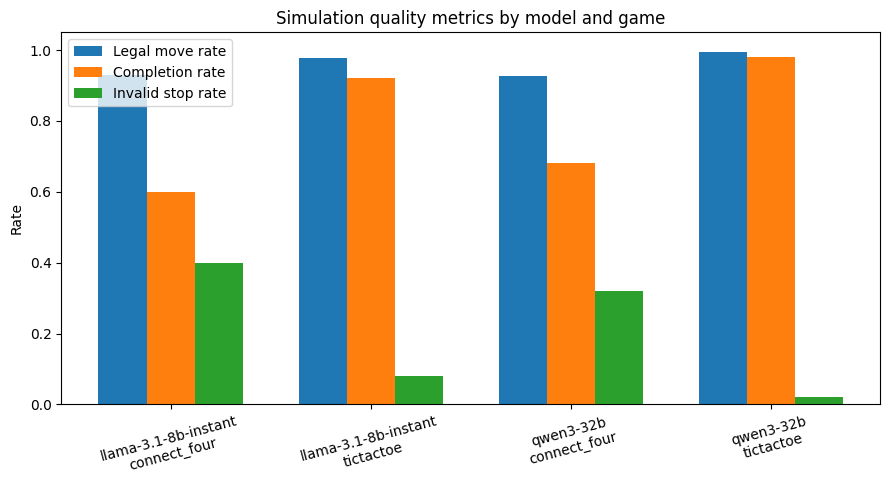

In [7]:
plot_df = sim_summary.copy()

fig, ax = plt.subplots(figsize=(9, 5))
labels = [f"{m.split('/')[-1]}\n{g}" for m, g in zip(plot_df["model"], plot_df["game"])]
x = range(len(labels))
w = 0.24

ax.bar([i - w for i in x], plot_df["legal_move_rate"], width=w, label="Legal move rate")
ax.bar(x, plot_df["completion_rate"], width=w, label="Completion rate")
ax.bar([i + w for i in x], plot_df["invalid_stop_rate"], width=w, label="Invalid stop rate")

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Rate")
ax.set_title("Simulation quality metrics by model and game")
ax.legend()
plt.tight_layout()
plt.show()


### Results and Analysis

Simulation results show that both models achieve high legal move rates (>0.92), indicating strong basic rule adherence during gameplay. Performance is consistently better for Tic-Tac-Toe than Connect Four across all metrics.

For Tic-Tac-Toe, both models achieve very high completion rates (0.92–0.98) and low invalid stop rates, with Qwen performing best overall (completion = 0.98, invalid stops = 0.02). In contrast, Connect Four shows lower completion rates (0.60–0.68) and higher invalid stops, reflecting the increased complexity of the game.

Qwen slightly outperforms Llama in Connect Four with higher completion and win rates, while both models perform comparably in Tic-Tac-Toe. The lower average number of valid turns in Connect Four further indicates that simulations often terminate early due to errors.

Overall, models can follow game rules reliably in simpler settings, but struggle to maintain consistent gameplay in more complex environments like Connect Four.

## Simulation Case Illustration

To complement the aggregate results, this section presents individual simulation examples that illustrate how the models behave during gameplay.

We include:
- one **successful case**, where the model follows the rules and completes the game correctly,  
- one **failure case**, where the simulation stops due to an invalid move or rule violation.

For each case, the board progression is shown step-by-step to highlight how the model makes decisions, how the game evolves, and where errors occur. This helps provide a clearer understanding of model behavior beyond summary metrics.

In [8]:
from src.analysis.experiment_utils import load_all_simulation_traces, show_simulation_cases

traces = load_all_simulation_traces()
show_simulation_cases(traces)

### Connect Four (Successful Case)
**Case ID:** `case_3`  
**Model:** `llama-3.1-8b-instant`  
**Stopped reason:** `terminal_state_reached`  
**Winner:** `O`  
**Turns:** `4`


<details>
<summary>Show board progression</summary>

#### Initial setup
```
. . . . . . .
. . . . . . .
. . . . . . .
. . O . . . .
O O O . . . .
X X X O . X X
```

#### Turn 1: X -> column 4
```
. . . . . . .
. . . . . . .
. . . . . . .
. . O . . . .
O O O . . . .
X X X O X X X
```

#### Turn 2: O -> column 2
```
. . . . . . .
. . . . . . .
. . O . . . .
. . O . . . .
O O O . . . .
X X X O X X X
```

#### Turn 3: X -> column 3
```
. . . . . . .
. . . . . . .
. . O . . . .
. . O . . . .
O O O X . . .
X X X O X X X
```

#### Turn 4: O -> column 2
```
. . . . . . .
. . O . . . .
. . O . . . .
. . O . . . .
O O O X . . .
X X X O X X X
```



</details>


### Connect Four (Failed Case)
**Case ID:** `case_2`  
**Model:** `llama-3.1-8b-instant`  
**Stopped reason:** `invalid_move`  
**Winner:** `None`  
**Turns:** `27`


<details>
<summary>Show board progression</summary>

#### Initial setup
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
```

#### Turn 1: X -> column 3
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
```

#### Turn 2: O -> column 4
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
```

#### Turn 3: X -> column 2
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . X X O . .
```

#### Turn 4: O -> column 4
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . O . .
. . X X O . .
```

#### Turn 5: X -> column 3
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
. . X X O . .
```

#### Turn 6: O -> column 2
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X O . .
. . X X O . .
```

#### Turn 7: X -> column 1
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X O . .
. X X X O . .
```

#### Turn 8: O -> column 1
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. O O X O . .
. X X X O . .
```

#### Turn 9: X -> column 4
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . X . .
. O O X O . .
. X X X O . .
```

#### Turn 10: O -> column 1
```
. . . . . . .
. . . . . . .
. . . . . . .
. O . . X . .
. O O X O . .
. X X X O . .
```

#### Turn 11: X -> column 2
```
. . . . . . .
. . . . . . .
. . . . . . .
. O X . X . .
. O O X O . .
. X X X O . .
```

#### Turn 12: O -> column 0
```
. . . . . . .
. . . . . . .
. . . . . . .
. O X . X . .
. O O X O . .
O X X X O . .
```

#### Turn 13: X -> column 3
```
. . . . . . .
. . . . . . .
. . . . . . .
. O X X X . .
. O O X O . .
O X X X O . .
```

#### Turn 14: O -> column 0
```
. . . . . . .
. . . . . . .
. . . . . . .
. O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 15: X -> column 1
```
. . . . . . .
. . . . . . .
. X . . . . .
. O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 16: O -> column 3
```
. . . . . . .
. . . . . . .
. X . O . . .
. O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 17: X -> column 3
```
. . . . . . .
. . . X . . .
. X . O . . .
. O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 18: O -> column 2
```
. . . . . . .
. . . X . . .
. X O O . . .
. O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 19: X -> column 0
```
. . . . . . .
. . . X . . .
. X O O . . .
X O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 20: O -> column 4
```
. . . . . . .
. . . X . . .
. X O O O . .
X O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 21: X -> column 1
```
. . . . . . .
. X . X . . .
. X O O O . .
X O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 22: O -> column 1
```
. O . . . . .
. X . X . . .
. X O O O . .
X O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 23: X -> column 3
```
. O . X . . .
. X . X . . .
. X O O O . .
X O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 24: O -> column 2
```
. O . X . . .
. X O X . . .
. X O O O . .
X O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 25: X -> column 2
```
. O X X . . .
. X O X . . .
. X O O O . .
X O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 26: O -> column 4
```
. O X X . . .
. X O X O . .
. X O O O . .
X O X X X . .
O O O X O . .
O X X X O . .
```

#### Turn 27: illegal move by X -> column 3 full
```
. O X X . . .
. X O X O . .
. X O O O . .
X O X X X . .
O O O X O . .
O X X X O . .
```



</details>


### Tic-Tac-Toe (Successful Case)
**Case ID:** `case_3`  
**Model:** `llama-3.1-8b-instant`  
**Stopped reason:** `terminal_state_reached`  
**Winner:** `X`  
**Turns:** `4`


<details>
<summary>Show board progression</summary>

#### Initial setup
```
. | . | .
. | . | .
X | . | .
```

#### Turn 1: O -> (1, 1)
```
. | . | .
. | O | .
X | . | .
```

#### Turn 2: X -> (0, 0)
```
X | . | .
. | O | .
X | . | .
```

#### Turn 3: O -> (0, 2)
```
X | . | O
. | O | .
X | . | .
```

#### Turn 4: X -> (1, 0)
```
X | . | O
X | O | .
X | . | .
```



</details>


### Tic-Tac-Toe (Failed Case)
**Case ID:** `case_36`  
**Model:** `llama-3.1-8b-instant`  
**Stopped reason:** `invalid_move`  
**Winner:** `None`  
**Turns:** `6`


<details>
<summary>Show board progression</summary>

#### Initial setup
```
O | . | .
. | . | .
. | . | X
```

#### Turn 1: X -> (0, 1)
```
O | X | .
. | . | .
. | . | X
```

#### Turn 2: O -> (1, 0)
```
O | X | .
O | . | .
. | . | X
```

#### Turn 3: X -> (1, 1)
```
O | X | .
O | X | .
. | . | X
```

#### Turn 4: O -> (2, 1)
```
O | X | .
O | X | .
. | O | X
```

#### Turn 5: X -> (1, 2)
```
O | X | .
O | X | X
. | O | X
```

#### Turn 6: illegal move by O -> (1, 0)
```
O | X | .
O | X | X
. | O | X
```



</details>


## Random Simulation Trace Illustration

In [9]:
from IPython.display import Markdown, display
from src.analysis.experiment_utils import reconstruct_cf_boards, board_to_block

case_id = "case_14"

case = next((c for c in traces if c.get("case_id") == case_id), None)

if case is None:
    print(f"Case {case_id} not found in raw traces.")
else:
    states = reconstruct_cf_boards(case)

    content = ""
    for label, board in states:
        board_rows = [row.split() for row in board.splitlines()]
        content += f"### {label}\n"
        content += board_to_block(board_rows) + "\n\n"

    display(Markdown(f"""
## Case {case_id} (click to expand)

<details>
<summary>Show full board progression</summary>

{content}

</details>
"""))


## Case case_14 (click to expand)

<details>
<summary>Show full board progression</summary>

### Initial setup
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . X .
X X X O . O .
```

### Turn 1: O -> column 3
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . O . X .
X X X O . O .
```

### Turn 2: X -> column 4
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . O . X .
X X X O X O .
```

### Turn 3: O -> column 1
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. O . O . X .
X X X O X O .
```

### Turn 4: X -> column 2
```
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. O X O . X .
X X X O X O .
```

### Turn 5: O -> column 1
```
. . . . . . .
. . . . . . .
. . . . . . .
. O . O . . .
. O X O . X .
X X X O X O .
```

### Turn 6: X -> column 1
```
. . . . . . .
. . . . . . .
. X . . . . .
. O . O . . .
. O X O . X .
X X X O X O .
```

### Turn 7: O -> column 6
```
. . . . . . .
. . . . . . .
. X . . . . .
. O . O . . .
. O X O . X .
X X X O X O O
```

### Turn 8: X -> column 3
```
. . . . . . .
. . . . . . .
. X . X . . .
. O . O . . .
. O X O . X .
X X X O X O O
```

### Turn 9: O -> column 0
```
. . . . . . .
. . . . . . .
. X . X . . .
. O . O . . .
O O X O . X .
X X X O X O O
```

### Turn 10: X -> column 2
```
. . . . . . .
. . . . . . .
. X . X . . .
. O X O . . .
O O X O . X .
X X X O X O O
```

### Turn 11: O -> column 4
```
. . . . . . .
. . . . . . .
. X . X . . .
. O X O . . .
O O X O O X .
X X X O X O O
```

### Turn 12: X -> column 0
```
. . . . . . .
. . . . . . .
. X . X . . .
X O X O . . .
O O X O O X .
X X X O X O O
```

### Turn 13: O -> column 0
```
. . . . . . .
. . . . . . .
O X . X . . .
X O X O . . .
O O X O O X .
X X X O X O O
```

### Turn 14: X -> column 1
```
. . . . . . .
. X . . . . .
O X . X . . .
X O X O . . .
O O X O O X .
X X X O X O O
```

### Turn 15: O -> column 3
```
. . . . . . .
. X . O . . .
O X . X . . .
X O X O . . .
O O X O O X .
X X X O X O O
```

### Turn 16: X -> column 3
```
. . . X . . .
. X . O . . .
O X . X . . .
X O X O . . .
O O X O O X .
X X X O X O O
```

### Turn 17: O -> column 0
```
. . . X . . .
O X . O . . .
O X . X . . .
X O X O . . .
O O X O O X .
X X X O X O O
```

### Turn 18: X -> column 4
```
. . . X . . .
O X . O . . .
O X . X . . .
X O X O X . .
O O X O O X .
X X X O X O O
```

### Turn 19: O -> column 4
```
. . . X . . .
O X . O . . .
O X . X O . .
X O X O X . .
O O X O O X .
X X X O X O O
```

### Turn 20: X -> column 4
```
. . . X . . .
O X . O X . .
O X . X O . .
X O X O X . .
O O X O O X .
X X X O X O O
```

### Turn 21: O -> column 4
```
. . . X O . .
O X . O X . .
O X . X O . .
X O X O X . .
O O X O O X .
X X X O X O O
```

### Turn 22: X -> column 2
```
. . . X O . .
O X . O X . .
O X X X O . .
X O X O X . .
O O X O O X .
X X X O X O O
```



</details>


In [10]:
from src.analysis.experiment_utils import load_all_simulation_traces, count_cases_continued_after_win

traces = load_all_simulation_traces()
continued_summary = count_cases_continued_after_win(traces)
continued_summary

,game,model,total_cases,initial_win_cases,continued_after_win_cases,avg_extra_turns_after_win
0,connect_four,llama-3.1-8b-instant,50,18,0,0.0
1,connect_four,qwen/qwen3-32b,50,18,0,0.0
2,tictactoe,llama-3.1-8b-instant,50,9,0,0.0
3,tictactoe,qwen/qwen3-32b,50,9,0,0.0


## Simulation Examples

### Connect Four
- **Success:** A valid multi-step game reaches a correct ending, showing the model can follow the rules throughout.  
- **Failure:** The game progresses for 27 turns but ends with an invalid move, indicating issues with tracking constraints over time.  
- **Random Case:** In a 22-turn game, all moves are valid, but the model does not block the opponent or choose winning moves, showing weak strategic reasoning.

### Tic-Tac-Toe
- **Success:** The model completes a short game correctly, handling basic multi-step play.  
- **Failure:** An invalid move occurs at turn 6, suggesting the model loses track of the board state.


Overall, the models follow rules well, but they struggle to maintain consistency over longer sequences and do not always make strong strategic decisions.

## 6. Game generation

This task looks at whether the models can produce a new board game with a clear objective, usable rules, and a coherent structure.

In [11]:
gen_df= pd.read_csv(root / "results" / "responses" /"game_generation"/ "generation_results.csv")

display(gen_df)

,model,clarity,consistency,balance,fun,coverage,playable
0,llama,5,5,2,5,1.0,True
1,qwen,5,5,4,5,1.0,True


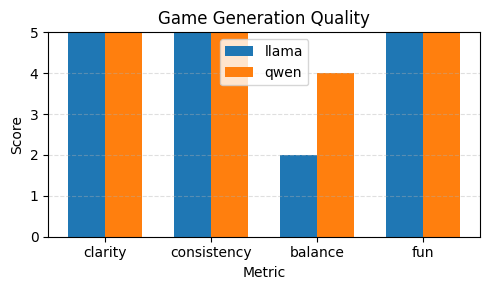

In [12]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["clarity", "consistency", "balance", "fun"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(x - width/2, gen_df.loc[0, metrics], width, label="llama")
ax.bar(x + width/2, gen_df.loc[1, metrics], width, label="qwen")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 5)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Game Generation Quality")

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Results and Analysis

Game generation was evaluated using heuristic scores (clarity, consistency, balance, fun, coverage) and a structural playability check.

Both models produce clear, consistent, and fully playable games. The main difference is in balance, where Qwen outperforms Llama, indicating better game design quality.

Taken together with earlier results, models perform well at generating structured descriptions but struggle with multi-step reasoning, making simulation a more challenging task.

## Final Conclusion

This project evaluated language models across rule understanding, error detection, game simulation, and game generation tasks using Tic-Tac-Toe and Connect Four.

The results show that both models perform well on structured tasks. In rule understanding and game generation, the models produce clear, complete, and well-organized outputs, with Qwen generally achieving better performance, especially in balance and rule coverage.

However, performance decreases in tasks that require multi-step reasoning. In error detection, both models achieve high recall but low precision, indicating that they can identify the presence of errors but often fail to precisely localize them. In simulation, while most moves are valid, failures occur due to incorrect state tracking and constraint handling, particularly in longer Connect Four games.

The case-based analysis further highlights this gap. Models can handle simple or near-terminal situations correctly, but struggle to maintain consistency over extended sequences and fail to make strategic decisions such as blocking or selecting optimal moves.

Overall, the results demonstrate that language models are strong in generating structured and interpretable outputs, but their reasoning remains limited in dynamic, sequential environments. This highlights the gap between rule understanding and reliable decision-making.